# Thesis Analysis: Charging Station Occupancy Classification

This notebook contains the complete analysis pipeline for the thesis:
1.  **Chronological Split:** Training on April-October, Testing on November-December.
2.  **Feature Engineering:** Creation of features to capture temporal dependencies.
3.  **Hyperparameter Tuning:** Grid Search for XGBoost.
4.  **Model Comparison:** Evaluating 5 models (Logistic Regression, KNN, Decision Tree, Random Forest, XGBoost).
5.  **Practical Predictions:** Generating real-world examples for the thesis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Data
We load the aggregated 15-minute window data. Note: The file path assumes you are running this in Colab. You may need to upload `acn_aggregated_time_windows_new.csv`.

In [2]:
# Load the dataset
# If running on Colab, upload the file first or mount Google Drive
try:
    df = pd.read_csv('acn_aggregated_time_windows_new.csv')
except FileNotFoundError:
    print("File not found. Please upload 'acn_aggregated_time_windows_new.csv' to the current directory.")

# Convert datetime columns
df['window_start'] = pd.to_datetime(df['window_start'])
df['window_end'] = pd.to_datetime(df['window_end'])
df['date'] = pd.to_datetime(df['date'])

# Sort by time to ensure chronological order
df = df.sort_values('window_start').reset_index(drop=True)

print(f"Total samples: {len(df)}")
df.head()

Total samples: 22272


,window_start,window_end,occupied_spaces,total_spaces,occupancy_rate,hour,minute,day_of_week,day_name,is_weekend,month,date,occupancy_class
0,2018-04-25 00:00:00,2018-04-25 00:15:00,0,54,0.0,0,0,2,Wednesday,0,4,2018-04-25,Not Busy
1,2018-04-25 00:15:00,2018-04-25 00:30:00,0,54,0.0,0,15,2,Wednesday,0,4,2018-04-25,Not Busy
2,2018-04-25 00:30:00,2018-04-25 00:45:00,0,54,0.0,0,30,2,Wednesday,0,4,2018-04-25,Not Busy
3,2018-04-25 00:45:00,2018-04-25 01:00:00,0,54,0.0,0,45,2,Wednesday,0,4,2018-04-25,Not Busy
4,2018-04-25 01:00:00,2018-04-25 01:15:00,0,54,0.0,1,0,2,Wednesday,0,4,2018-04-25,Not Busy


## 2. Feature Engineering
Creation of **Engineered Features** from the original features.

In [3]:
# Base Features
df['hour'] = df['window_start'].dt.hour
df['day_of_week'] = df['window_start'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['month'] = df['window_start'].dt.month
df['minute'] = df['window_start'].dt.minute

# Cyclical Features (Sine/Cosine Transform)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Domain Flags
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if 18 <= x <= 22 else 0)
df['is_morning'] = df['hour'].apply(lambda x: 1 if 7 <= x <= 12 else 0)

# Target Variable (Median Threshold)
median_occupancy = df['occupied_spaces'].median()
df['occupancy_class'] = (df['occupied_spaces'] > median_occupancy).astype(int)

# --- NEW: Lag Features ---
# Lag 1h: Occupancy status 4 steps ago (15 min * 4 = 60 min)
df['occupancy_lag_1h'] = df['occupancy_class'].shift(4).fillna(0)
# Lag 24h: Occupancy status 96 steps ago (15 min * 4 * 24 = 1 day)
df['occupancy_lag_24h'] = df['occupancy_class'].shift(96).fillna(0)

# Drop rows with NaN values created by shifting
df = df.dropna().reset_index(drop=True)

print(f"Samples after dropping NaNs: {len(df)}")

Samples after dropping NaNs: 22272


## 3. Chronological Train-Test Split
Instead of a random split, we split by date:
*   **Train:** April - October 2018
*   **Test:** November - December 2018

In [4]:
split_date = '2018-11-01'
train_df = df[df['window_start'] < split_date]
test_df = df[df['window_start'] >= split_date]

features = ['hour', 'day_of_week', 'is_weekend', 'month', 'minute',
            'hour_sin', 'hour_cos', 'is_peak_hour', 'day_sin', 'day_cos',
            'is_morning', 'occupancy_lag_1h', 'occupancy_lag_24h']

X_train = train_df[features]
y_train = train_df['occupancy_class']
X_test = test_df[features]
y_test = test_df['occupancy_class']

print(f"Training Set: {len(X_train)} samples ({len(X_train)/len(df):.1%})")
print(f"Testing Set: {len(X_test)} samples ({len(X_test)/len(df):.1%})")

# Check Class Balance
print("\nTraining Class Balance:")
print(y_train.value_counts(normalize=True))
print("\nTesting Class Balance:")
print(y_test.value_counts(normalize=True))

Training Set: 18240 samples (81.9%)
Testing Set: 4032 samples (18.1%)

Training Class Balance:
occupancy_class
1    0.527029
0    0.472971
Name: proportion, dtype: float64

Testing Class Balance:
occupancy_class
0    0.683036
1    0.316964
Name: proportion, dtype: float64


## 4. Model Training & Tuning
We train 5 models. For XGBoost, we perform Hyperparameter Tuning.

In [5]:
# Initialize Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train Baseline Models
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob),
        'Model': model  # Save model object for later use
    }

# --- XGBoost Tuning ---
print("Tuning XGBoost...")
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200]
}

# TimeSeriesSplit for validation
tscv = TimeSeriesSplit(n_splits=3)
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=tscv, scoring='f1', verbose=1)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print(f"Best XGBoost Params: {grid_search.best_params_}")

# Evaluate Best XGBoost
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

results['XGBoost (Tuned)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'AUC': roc_auc_score(y_test, y_prob_xgb),
    'Model': best_xgb
}

Training Logistic Regression...
Training KNN...
Training Decision Tree...
Training Random Forest...
Tuning XGBoost...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:53:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:53:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:53:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:53:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best XGBoost Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}


## 5. Results & Visualization
Generating of Confusion Matrix, ROC Curves, and Feature Importance for XG Boost

Model Performance Metrics:


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.880952,0.732517,0.983568,0.839679,0.985358
XGBoost (Tuned),0.857639,0.696429,0.976526,0.813029,0.980321
Random Forest,0.837054,0.671832,0.949922,0.787034,0.961993
Decision Tree,0.826637,0.656911,0.948357,0.776177,0.871759
KNN,0.762649,0.573054,0.985133,0.724604,0.902635


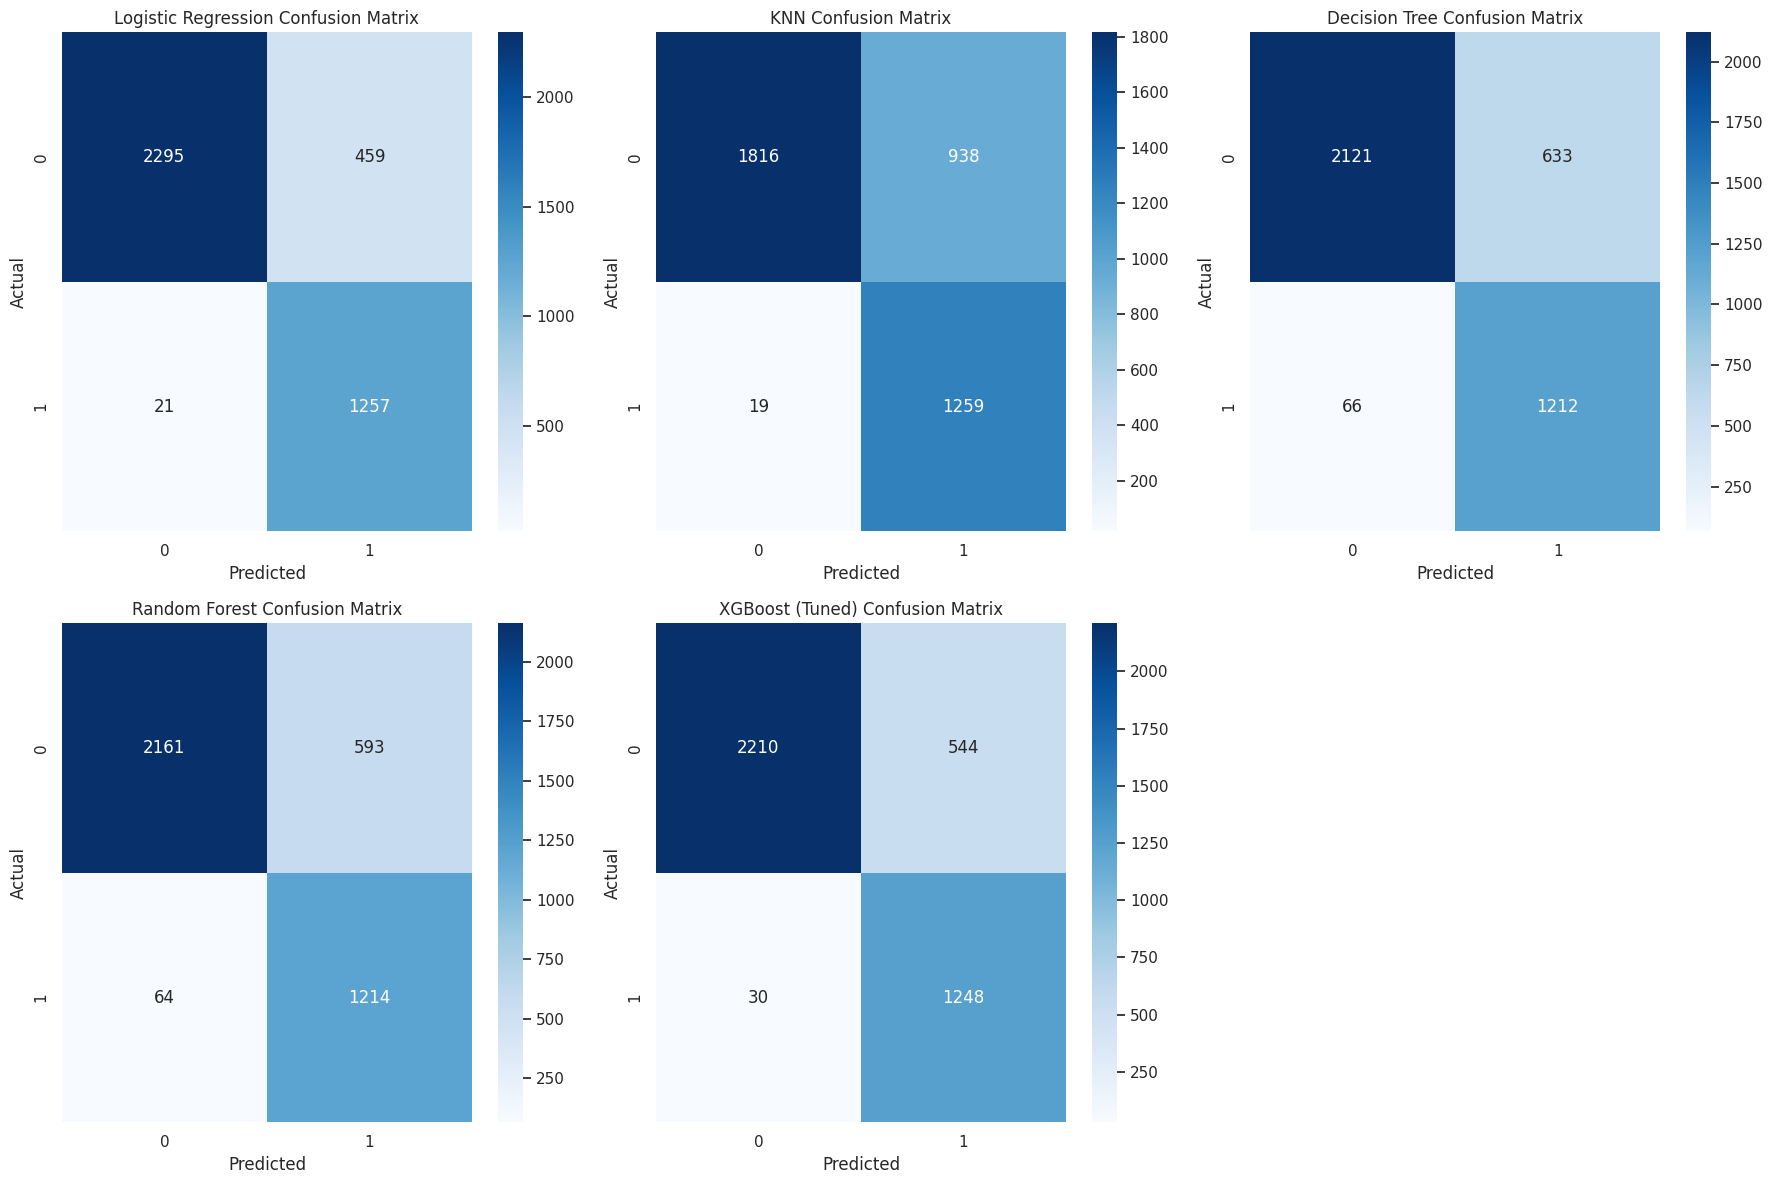

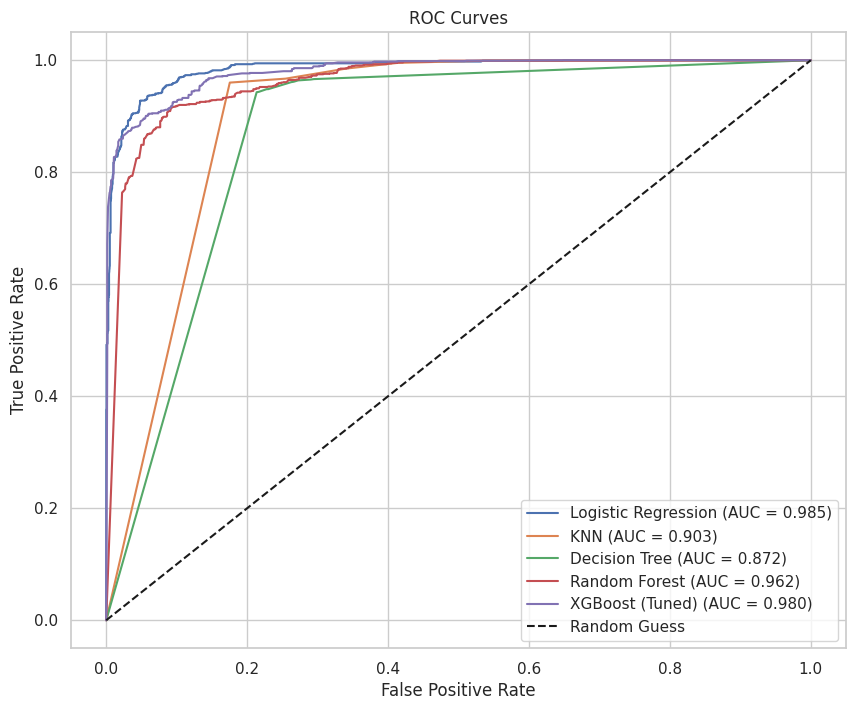

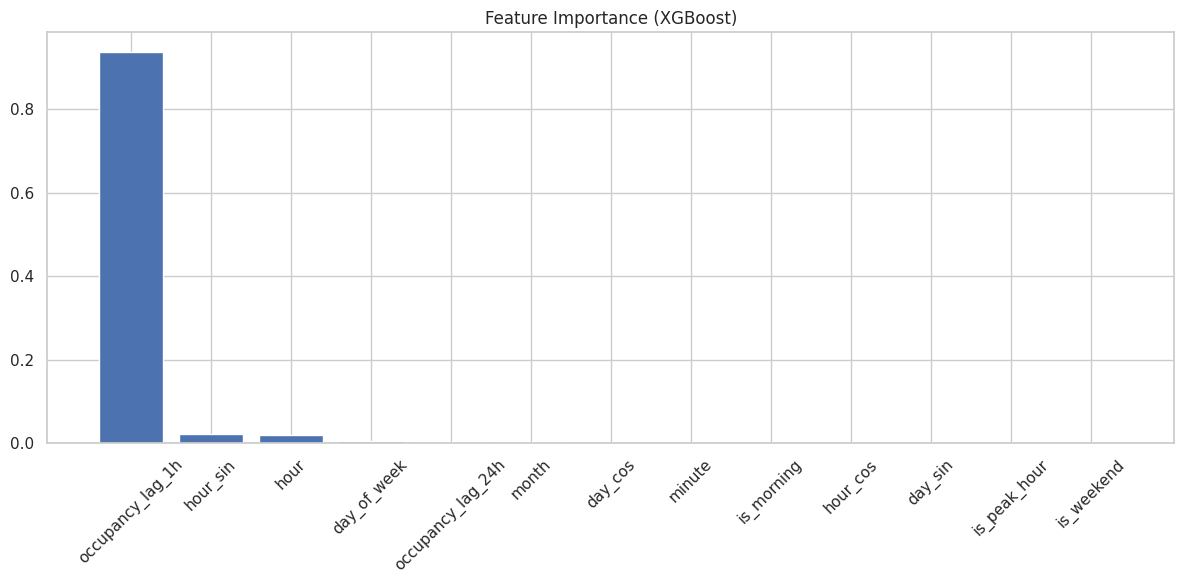

In [6]:
# Create Performance Table
metrics_df = pd.DataFrame(results).T.drop(columns=['Model'])
metrics_df = metrics_df.sort_values('F1-Score', ascending=False)
print("Model Performance Metrics:")
display(metrics_df)

# --- Plot 1: Confusion Matrices ---
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['Model'].predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide empty subplot if any
if len(results) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

# --- Plot 2: ROC Curves ---
plt.figure(figsize=(10, 8))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['Model'].predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# --- Plot 3: Feature Importance (XGBoost) ---
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importance (XGBoost)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

## 6. Practical Predictions
Generating the real-world examples.

In [7]:
scenarios = [
    {'desc': 'Monday Morning (08:00)', 'day': 0, 'hour': 8, 'minute': 0},
    {'desc': 'Wednesday Afternoon (14:30)', 'day': 2, 'hour': 14, 'minute': 30},
    {'desc': 'Tuesday Evening Peak (19:00)', 'day': 1, 'hour': 19, 'minute': 0},
    {'desc': 'Thursday Night (21:15)', 'day': 3, 'hour': 21, 'minute': 15},
    {'desc': 'Saturday Morning (10:00)', 'day': 5, 'hour': 10, 'minute': 0},
    {'desc': 'Monday Evening (20:45)', 'day': 0, 'hour': 20, 'minute': 45},
    {'desc': 'Sunday Morning (09:00)', 'day': 6, 'hour': 9, 'minute': 0},
    {'desc': 'Friday Night (22:30)', 'day': 4, 'hour': 22, 'minute': 30}
]

print("--- Practical Predictions (Test Set: Nov-Dec) ---")
print(f"{'Scenario':<30} {'Day':<10} {'Time':<10} {'Prediction':<10} {'Confidence':<10}")
print("-" * 75)

for s in scenarios:
    # Find matching rows in test set
    matches = test_df[
        (test_df['day_of_week'] == s['day']) &
        (test_df['hour'] == s['hour']) &
        (test_df['minute'] == s['minute'])
    ]

    if not matches.empty:
        # Take the first match
        row = matches.iloc[0]
        X_sample = row[features].to_frame().T.astype(float)
        pred = best_xgb.predict(X_sample)[0]
        prob = best_xgb.predict_proba(X_sample)[0]
        confidence = prob[pred]

        pred_str = "BUSY" if pred == 1 else "NOT BUSY"
        day_name = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'][s['day']]
        time_str = f"{s['hour']:02d}:{s['minute']:02d}"

        print(f"{s['desc']:<30} {day_name:<10} {time_str:<10} {pred_str:<10} {confidence:.1%}")

--- Practical Predictions (Test Set: Nov-Dec) ---
Scenario                       Day        Time       Prediction Confidence
---------------------------------------------------------------------------
Monday Morning (08:00)         Monday     08:00      NOT BUSY   92.7%
Wednesday Afternoon (14:30)    Wednesday  14:30      BUSY       69.2%
Tuesday Evening Peak (19:00)   Tuesday    19:00      BUSY       93.4%
Thursday Night (21:15)         Thursday   21:15      BUSY       93.4%
Saturday Morning (10:00)       Saturday   10:00      NOT BUSY   88.9%
Monday Evening (20:45)         Monday     20:45      BUSY       93.1%
Sunday Morning (09:00)         Sunday     09:00      NOT BUSY   92.7%
Friday Night (22:30)           Friday     22:30      BUSY       93.4%
